In [1]:
import tensorflow as tf

# ===============================
# 0. GPU Check
# ===============================
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Using GPU: ", tf.test.gpu_device_name())

from google.colab import drive
drive.mount('/content/drive')

# Install requirements
!apt install unrar
!pip install pyunpack patool

from pyunpack import Archive
import os

# ===============================
# 1. Extract Dataset
# ===============================
rar_path = '/content/drive/MyDrive/Colab Dataset/data.rar'
extract_path = '/content/Dataset'
os.makedirs(extract_path, exist_ok=True)
Archive(rar_path).extractall(extract_path)

Num GPUs Available:  1
Using GPU:  /device:GPU:0
Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.5/86.5 kB 9.4 MB/s eta 0:00:00


In [2]:
# ===============================
# 2. Import Libraries
# ===============================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
# ===============================
# 3. Dataset Paths
# ===============================
data_root = '/content/Dataset/data/Recognition'
train_dir = os.path.join(data_root, 'train')
val_dir   = os.path.join(data_root, 'validation')
test_dir  = os.path.join(data_root, 'test')

image_size = (256, 256)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=True, seed=seed
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False, seed=seed
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, labels='inferred', label_mode='int',
    image_size=image_size, batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 26097 files belonging to 9 classes.
Found 1634 files belonging to 9 classes.
Found 1144 files belonging to 9 classes.
Classes: ['1000_taka', '100_taka', '10_taka', '200_taka', '20_taka', '2_taka', '500_taka', '50_taka', '5_taka']


In [4]:
# ===============================
# 4. Data Prefetching for Performance
# ===============================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [5]:
# ===============================
# 5. Build DenseNet121 Model
# ===============================
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import Model, Input

def create_densenet121(input_shape=(256,256,3), num_classes=9):
    base_model = DenseNet121(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model for feature extraction

    inputs = Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    x = base_model(x, training=False)  # Use DenseNet121 as feature extractor
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="densenet121_currency")
    return model

model = create_densenet121(input_shape=(image_size[0], image_size[1], 3), num_classes=num_classes)
model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "densenet121_currency"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 8, 8, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,566,921 (28.87 MB)

 Trainable params: 529,417 (2.02 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [6]:
# ===============================
# 6. Compile Model
# ===============================
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ===============================
# 7. Callbacks
# ===============================
checkpoint_path = "best_densenet121_currency.h5"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

In [7]:

# ===============================
# 8. Train Model
# ===============================
epochs = 30
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

# Save final model
model.save("DenseNet121_Bangla_Currency_Recognition.h5")

Epoch 1/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3782 - loss: 1.7814
Epoch 1: val_loss improved from inf to 0.64218, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 144s 136ms/step - accuracy: 0.3784 - loss: 1.7809 - val_accuracy: 0.8647 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 2/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7596 - loss: 0.7798
Epoch 2: val_loss improved from 0.64218 to 0.36762, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 90s 94ms/step - accuracy: 0.7597 - loss: 0.7796 - val_accuracy: 0.9162 - val_loss: 0.3676 - learning_rate: 1.0000e-04
Epoch 3/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8470 - loss: 0.5156
Epoch 3: val_loss improved from 0.36762 to 0.26368, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 76s 93ms/step - accuracy: 0.8470 - loss: 0.5156 - val_accuracy: 0.9345 - val_loss: 0.2637 - learning_rate: 1.0000e-04
Epoch 4/30
815/816 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8847 - loss: 0.3920
Epoch 4: val_loss improved from 0.26368 to 0.20624, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 93ms/step - accuracy: 0.8847 - loss: 0.3920 - val_accuracy: 0.9474 - val_loss: 0.2062 - learning_rate: 1.0000e-04
Epoch 5/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9070 - loss: 0.3187
Epoch 5: val_loss improved from 0.20624 to 0.17321, saving model to best_densenet121_currency.h5


...

816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.9877 - loss: 0.0517 - val_accuracy: 0.9804 - val_loss: 0.0578 - learning_rate: 1.0000e-04
Epoch 24/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9873 - loss: 0.0494
Epoch 24: val_loss improved from 0.05778 to 0.05756, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.9873 - loss: 0.0494 - val_accuracy: 0.9835 - val_loss: 0.0576 - learning_rate: 1.0000e-04
Epoch 25/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9900 - loss: 0.0430
Epoch 25: val_loss improved from 0.05756 to 0.05444, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 95ms/step - accuracy: 0.9900 - loss: 0.0430 - val_accuracy: 0.9841 - val_loss: 0.0544 - learning_rate: 1.0000e-04
Epoch 26/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9886 - loss: 0.0435
Epoch 26: val_loss did not improve from 0.05444
816/816 ━━━━━━━━━━━━━━━━━━━━ 81s 94ms/step - accuracy: 0.9886 - loss: 0.0435 - val_accuracy: 0.9859 - val_loss: 0.0545 - learning_rate: 1.0000e-04
Epoch 27/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9892 - loss: 0.0421
Epoch 27: val_loss did not improve from 0.05444
816/816 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - accuracy: 0.9892 - loss: 0.0421 - val_accuracy: 0.9865 - val_loss: 0.0562 - learning_rate: 1.0000e-04
Epoch 28/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9927 - loss: 0.0360
Epoch 28: val_loss improved from 0.05444 to 0.05435, saving model to best_densenet121_currency.h5



Epoch 28: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
816/816 ━━━━━━━━━━━━━━━━━━━━ 84s 96ms/step - accuracy: 0.9927 - loss: 0.0360 - val_accuracy: 0.9810 - val_loss: 0.0544 - learning_rate: 1.0000e-04
Epoch 29/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9934 - loss: 0.0322
Epoch 29: val_loss improved from 0.05435 to 0.04919, saving model to best_densenet121_currency.h5


816/816 ━━━━━━━━━━━━━━━━━━━━ 82s 96ms/step - accuracy: 0.9934 - loss: 0.0322 - val_accuracy: 0.9847 - val_loss: 0.0492 - learning_rate: 5.0000e-05
Epoch 30/30
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9937 - loss: 0.0289
Epoch 30: val_loss did not improve from 0.04919
816/816 ━━━━━━━━━━━━━━━━━━━━ 80s 94ms/step - accuracy: 0.9937 - loss: 0.0289 - val_accuracy: 0.9847 - val_loss: 0.0494 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 29.


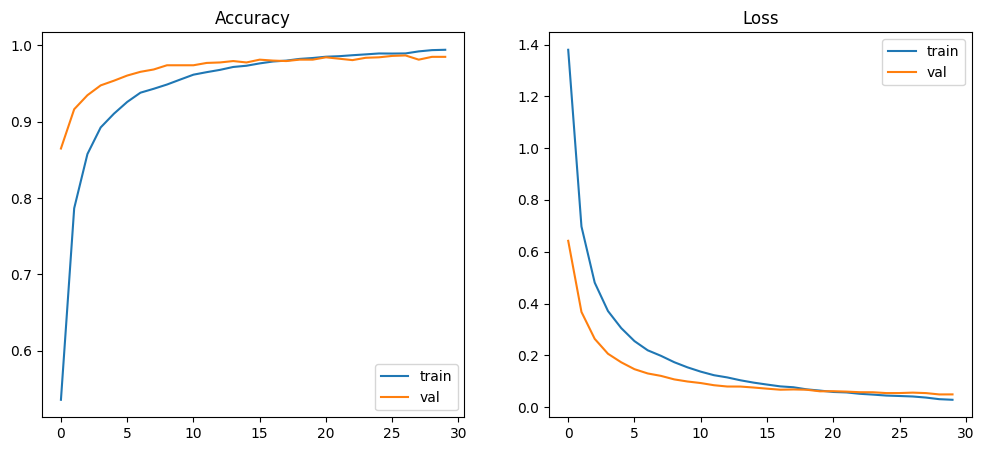

In [8]:
# ===============================
# 9. Plot Training History
# ===============================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.show()

In [9]:
# ===============================
# 10. Evaluation on Test Data
# ===============================
y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

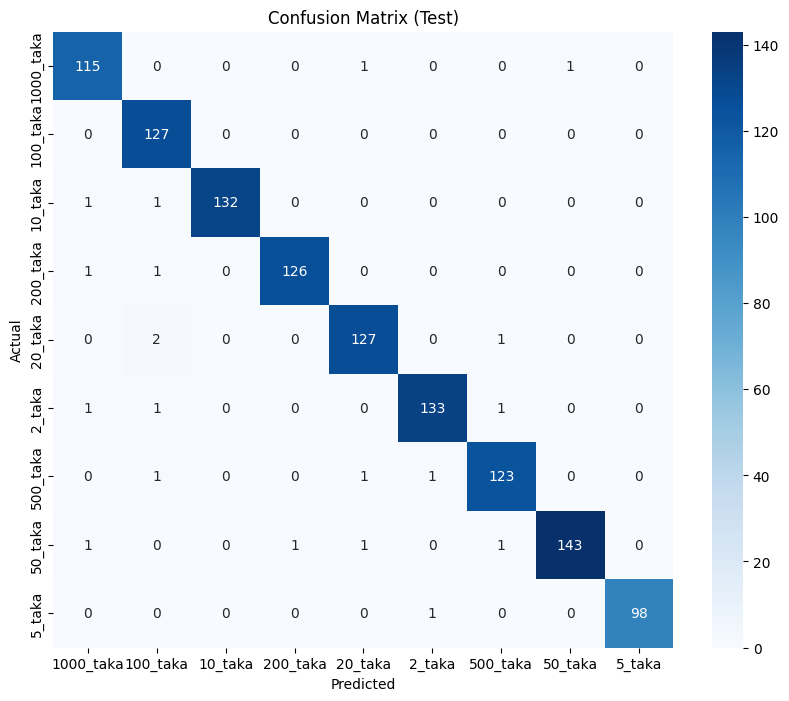

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test)')
plt.show()

In [11]:

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

   1000_taka       0.97      0.98      0.97       117
    100_taka       0.95      1.00      0.98       127
     10_taka       1.00      0.99      0.99       134
    200_taka       0.99      0.98      0.99       128
     20_taka       0.98      0.98      0.98       130
      2_taka       0.99      0.98      0.98       136
    500_taka       0.98      0.98      0.98       126
     50_taka       0.99      0.97      0.98       147
      5_taka       1.00      0.99      0.99        99

    accuracy                           0.98      1144
   macro avg       0.98      0.98      0.98      1144
weighted avg       0.98      0.98      0.98      1144

